In [1]:
# 로컬 실행용 경로 설정 (Google Colab Drive 마운트 불필요)
import os

BASE_DIR  = os.path.abspath("..")          # project root
OUT_DIR   = os.path.join(BASE_DIR, "pipeline_이유준")
os.makedirs(OUT_DIR, exist_ok=True)
print(f"BASE_DIR: {BASE_DIR}")
print(f"OUT_DIR:  {OUT_DIR}")


BASE_DIR: c:\Users\user\Desktop\project_DScover_연합학술제_GNN
OUT_DIR:  c:\Users\user\Desktop\project_DScover_연합학술제_GNN\pipeline_이유준


In [2]:
import pandas as pd
import numpy as np
import os

BASE_DIR  = os.path.abspath("..")
DATA_PATH = os.path.join(BASE_DIR, "data", "yelpzip.csv")
OUT_DIR   = os.path.join(BASE_DIR, "pipeline_이유준")
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df = df.rename(columns={df.columns[0]: "idx"})

print(f"Shape: {df.shape}")
df.head(3)

Shape: (608458, 8)


,idx,user_id,prod_id,rating,label,date,text,tag
0,0,5044,0,1.0,-1,2014-11-16,"Drinks were bad, the hot chocolate was watered...",fake
1,1,5045,0,1.0,-1,2014-09-08,This was the worst experience I've ever had a ...,fake
2,2,5046,0,3.0,-1,2013-10-06,This is located on the site of the old Spruce ...,fake


## Step 1. 필수 레이블 변환

원본 YelpZip: 사기 `-1` → `1`, 정상 `1` → `0`

| 원본 label | 변환 후 | 의미 |
|:---:|:---:|:---:|
| -1 | 1 | 사기 리뷰 (Fraud) |
| 1 | 0 | 정상 리뷰 (Legit) |

In [3]:
print("변환 전:")
print(df["label"].value_counts())

df["label"] = df["label"].map({-1: 1, 1: 0})

print("\n변환 후:")
print(df["label"].value_counts())

assert df["label"].isnull().sum() == 0, "변환 후 결측치 발생"
assert set(df["label"].unique()) == {0, 1}, "예상치 못한 레이블 값 존재"

변환 전:
label
 1    528019
-1     80439
Name: count, dtype: int64

변환 후:
label
0    528019
1     80439
Name: count, dtype: int64


## Step 2. 기본 정제

- `idx` / `tag` 컬럼 제거
- `date` → datetime 파싱 후 `year`, `month`, `year_month` 파생
- `rating` float → int 변환
- 결측치 및 빈 텍스트 확인

In [4]:
df = df.drop(columns=["idx", "tag"])

df["date"]       = pd.to_datetime(df["date"])
df["year"]       = df["date"].dt.year
df["month"]      = df["date"].dt.month
df["year_month"] = df["date"].dt.to_period("M").astype(str)
df["rating"]     = df["rating"].astype(float).astype(int)

print("결측치:")
print(df.isnull().sum())
print(f"\n빈 텍스트 행: {(df['text'].str.strip() == '').sum()}")
print("\n최종 컬럼:")
print(df.dtypes)

결측치:
user_id       0
prod_id       0
rating        0
label         0
date          0
text          0
year          0
month         0
year_month    0
dtype: int64

빈 텍스트 행: 0

최종 컬럼:
user_id                int64
prod_id                int64
rating                 int64
label                  int64
date          datetime64[us]
text                     str
year                   int32
month                  int32
year_month               str
dtype: object


## Step 3. 서브그래프 샘플링 (전략 C)

2011~2013년 중 사기 건수가 가장 많은 연월을 내림차순으로 누적 선택, 45,000 노드 이하로 제한.

- 사기 집중 시간대 우선 포함 → 학습 신호 품질 극대화
- 선택된 연월이 R-T-R 엣지의 직접 근거

In [5]:
FRAUD_PEAK_YEARS = [2011, 2012, 2013]
MAX_NODES = 45000

df_peak = df[df["year"].isin(FRAUD_PEAK_YEARS)].copy()

ym_stats = (
    df_peak.groupby("year_month")["label"]
    .agg(전체="count", 사기="sum")
    .reset_index()
)
ym_stats = ym_stats.sort_values("사기", ascending=False).reset_index(drop=True)

selected_ym, total_nodes = [], 0
for _, row in ym_stats.iterrows():
    if total_nodes + row["전체"] <= MAX_NODES:
        selected_ym.append(row["year_month"])
        total_nodes += int(row["전체"])

df_sub = df_peak[df_peak["year_month"].isin(selected_ym)].copy().reset_index(drop=True)

print(f"선택된 연월: {sorted(selected_ym)}")
print(f"서브그래프 노드 수: {len(df_sub):,}")
print(f"사기 비율: {df_sub['label'].mean()*100:.1f}%")

assert 10000 <= len(df_sub) <= 50000

선택된 연월: ['2013-03', '2013-04', '2013-07', '2013-08']
서브그래프 노드 수: 44,776
사기 비율: 14.6%


## Step 4. 노드 인덱스 재부여

GNN 엣지 생성을 위해 0부터 시작하는 연속 정수 인덱스로 재매핑한다.

- `node_id`: 0 ~ N-1
- `user_int`, `prod_int`: user_id / prod_id → 정수 딕셔너리

In [6]:
df_sub = df_sub.reset_index(drop=True)
df_sub["node_id"] = df_sub.index

user_map = {u: i for i, u in enumerate(df_sub["user_id"].unique())}
prod_map = {p: i for i, p in enumerate(df_sub["prod_id"].unique())}

df_sub["user_int"] = df_sub["user_id"].map(user_map)
df_sub["prod_int"] = df_sub["prod_id"].map(prod_map)

print(f"노드 수: {len(df_sub):,}")
print(f"고유 유저 수: {len(user_map):,}")
print(f"고유 상품 수: {len(prod_map):,}")
print(df_sub[["node_id", "user_id", "user_int", "prod_id", "prod_int", "rating", "label", "year_month"]].head(5))

노드 수: 44,776
고유 유저 수: 28,585
고유 상품 수: 3,214
   node_id  user_id  user_int  prod_id  prod_int  rating  label year_month
0        0     5049         0        0         0       5      1    2013-07
1        1     5050         1        0         0       5      1    2013-03
2        2     5104         2        0         0       3      0    2013-07
3        3     5105         3        0         0       4      0    2013-07
4        4     5106         4        0         0       4      0    2013-07


## Step 5. 노드 피처 엔지니어링 — 28개 파생변수

| 카테고리 | 변수 수 | 출처 |
|:---:|:---:|:---|
| A. Sentiment | 6 | 신동훈(2022) LIWC + VADER |
| B. Text Authenticity | 6 | 팀 가설 2, 3 |
| C. Template Proxy | 3 | 팀 가설 4 |
| D. POS & Pronoun | 5 | 신동훈(2022) LIWC + spaCy |
| E. Behavioral | 4 | 팀 가설 1, 5 + Zhang et al.(2026) |
| F. Network Proxy | 4 | Zhang et al.(2026) DS-DGA-GCN |

**처리 전략**: spaCy로 전체 텍스트를 **한 번만 파싱** → B/C/D 피처 동시 추출.  
Sentiment(A)는 VADER로 별도 처리 (자체 토크나이저 사용).

In [7]:
!pip install vaderSentiment -q
!python -m spacy download en_core_web_sm -q

import re, tqdm
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import spacy

!apt-get install -y fonts-nanum > /dev/null 2>&1
fm._load_fontmanager(try_read_cache=False)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

nlp      = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer"])
analyzer = SentimentIntensityAnalyzer()
texts    = df_sub["text"].fillna("").astype(str).tolist()

print(f"처리 대상: {len(texts):,}개")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
처리 대상: 44,776개


In [8]:
import tqdm

CONTRACTION_PAT = re.compile(
    r"\b\w+n't\b|\b(i'm|i've|i'd|i'll|you're|you've|it's|that's|there's|"
    r"they're|we're|can't|won't|don't|didn't|isn't|wasn't|couldn't|wouldn't|shouldn't)\b",
    re.IGNORECASE
)
PPRON_I_SET  = {"i", "me", "my", "mine", "myself"}
FUTURE_WORDS = {"will", "would", "'ll", "gonna"}
BATCH_SIZE   = 512

(wc_r, avg_wl_r, caps_r, contraction_r, oov_r, punct_r,
 analytic_r, ttr_r, verb_r, adj_r, adverb_r, ppron_i_r, focuspast_r) = [[] for _ in range(13)]

for doc in tqdm.tqdm(nlp.pipe(texts, batch_size=BATCH_SIZE), total=len(texts), desc="spaCy"):
    tokens = [t for t in doc if not t.is_space]
    words  = [t for t in tokens if t.is_alpha]
    n = max(len(tokens), 1)
    w = max(len(words), 1)

    wc_r.append(len(words))
    avg_wl_r.append(sum(len(t.text) for t in words) / w)
    caps_r.append(sum(1 for t in words if t.text.isupper() and len(t.text) > 1) / w)
    contraction_r.append(len(CONTRACTION_PAT.findall(doc.text)) / w)
    oov_r.append(sum(1 for t in words if t.is_oov) / w)
    punct_r.append(sum(1 for t in tokens if t.is_punct) / n)
    analytic_r.append(sum(1 for t in words if len(t.text) > 6) / w)
    ttr_r.append(len({t.text.lower() for t in words}) / w)
    verb_r.append(sum(1 for t in doc if t.pos_ == "VERB") / n)
    adj_r.append(sum(1 for t in doc if t.pos_ == "ADJ") / n)
    adverb_r.append(sum(1 for t in doc if t.pos_ == "ADV") / n)
    ppron_i_r.append(sum(1 for t in doc if t.pos_ == "PRON" and t.text.lower() in PPRON_I_SET) / n)
    focuspast_r.append(sum(1 for t in doc if t.tag_ in {"VBD", "VBN"}) / n)

print("spaCy 단일 패스 완료.")

spaCy:   0%|          | 0/44776 [00:00<?, ?it/s]

spaCy: 100%|██████████| 44776/44776 [27:46<00:00, 26.87it/s]  

spaCy 단일 패스 완료.


### Step 5-1. Sentiment (6개) — VADER
**출처**: 신동훈(2022) LIWC2015 Sentiment 카테고리(tone_pos, tone_neg, emotion, emo_pos, emo_neg, emo_anger) 참조, 유료 LIWC 대신 VADER로 재현

| 변수 | 설명 |
|:---|:---|
| tone_pos | 긍정 감성 단어 비율 (VADER pos score) |
| tone_neg | 부정 감성 단어 비율 (VADER neg score) |
| emotion | 감성 강도 절댓값 \|compound\| — 감정이 얼마나 강한지 |
| emo_pos | 긍정 방향 감성 강도 (compound > 0이면 compound, 아니면 0) |
| emo_neg | 부정 방향 감성 강도 (compound < 0이면 \|compound\|, 아니면 0) |
| emo_anger | 분노 단어 비율 (hate, furious, awful 등 anger word list 기반) |

> 사기 리뷰는 **tone_pos 높고** (과도한 긍정), **emo_anger 낮은** 경향 — 신동훈(2022)

In [9]:
ANGER_WORDS = {
    "angry","anger","hate","hatred","furious","rage","mad","annoyed",
    "irritated","frustrated","outraged","disgusted","disgust","terrible",
    "awful","horrible","worst","rude","nasty","offensive","appalled"
}

vader_results = [analyzer.polarity_scores(t) for t in texts]

df_sub["tone_pos"]  = [r["pos"] for r in vader_results]
df_sub["tone_neg"]  = [r["neg"] for r in vader_results]
df_sub["emotion"]   = [abs(r["compound"]) for r in vader_results]
df_sub["emo_pos"]   = [max(r["compound"], 0) for r in vader_results]
df_sub["emo_neg"]   = [abs(min(r["compound"], 0)) for r in vader_results]
df_sub["emo_anger"] = [
    len([w for w in t.lower().split() if w in ANGER_WORDS]) / max(len(t.split()), 1)
    for t in texts
]

sent_cols = ["tone_pos", "tone_neg", "emotion", "emo_pos", "emo_neg", "emo_anger"]
print("Sentiment 피처 (6개):")
print(df_sub[sent_cols].describe().round(4))

Sentiment 피처 (6개):
         tone_pos    tone_neg     emotion     emo_pos     emo_neg   emo_anger
count  44776.0000  44776.0000  44776.0000  44776.0000  44776.0000  44776.0000
mean       0.2171      0.0372      0.8331      0.7882      0.0449      0.0007
std        0.1305      0.0514      0.2279      0.3048      0.1727      0.0052
min        0.0000      0.0000      0.0000      0.0000      0.0000      0.0000
25%        0.1340      0.0000      0.7906      0.7578      0.0000      0.0000
50%        0.1960      0.0230      0.9348      0.9325      0.0000      0.0000
75%        0.2710      0.0540      0.9783      0.9781      0.0000      0.0000
max        1.0000      1.0000      0.9998      0.9998      0.9976      0.2500


### Step 5-2. Text Authenticity (6개) — spaCy
**출처**: 팀 가설 2 (정제된 문체 vs 구어체/오탈자), 팀 가설 3 (대문자 강조, 구두점)

| 변수 | 설명 | 가설 |
|:---|:---|:---:|
| WC | 단어 수 | 2 |
| avg_word_len | 평균 단어 길이 → 높을수록 정제된 문체 = 사기 가능성 | 2 |
| caps_ratio | ALL-CAPS 단어 비율 (AMAZING, TERRIBLE 등) → 높을수록 정상 | 3 |
| contraction_ratio | 축약형(don't, it's, can't) 비율 → 높을수록 정상 (구어체) | 2 |
| oov_ratio | spaCy OOV 단어 비율 (오탈자/슬랭 근사) → 높을수록 정상 | 2 |
| punct_ratio | 구두점(!, ?, .) 비율 → 높을수록 감정적 정상 리뷰 | 3 |

In [10]:
df_sub["WC"]               = wc_r
df_sub["avg_word_len"]     = avg_wl_r
df_sub["caps_ratio"]       = caps_r
df_sub["contraction_ratio"]= contraction_r
df_sub["oov_ratio"]        = oov_r
df_sub["punct_ratio"]      = punct_r

auth_cols = ["WC", "avg_word_len", "caps_ratio", "contraction_ratio", "oov_ratio", "punct_ratio"]
print("Text Authenticity 피처 (6개):")
print(df_sub[auth_cols].describe().round(4))

Text Authenticity 피처 (6개):
               WC  avg_word_len  caps_ratio  contraction_ratio   oov_ratio  \
count  44776.0000    44776.0000  44776.0000         44776.0000  44776.0000   
mean     111.4185        4.3086      0.0076             0.0153      0.9999   
std      106.0734        0.4464      0.0234             0.0198      0.0116   
min        0.0000        0.0000      0.0000             0.0000      0.0000   
25%       40.0000        4.0600      0.0000             0.0000      1.0000   
50%       81.0000        4.2530      0.0000             0.0102      1.0000   
75%      148.0000        4.4775      0.0071             0.0238      1.0000   
max     1472.0000       13.0000      1.0000             0.4000      1.0000   

       punct_ratio  
count   44776.0000  
mean        0.1321  
std         0.0550  
min         0.0000  
25%         0.1017  
50%         0.1250  
75%         0.1512  
max         1.0000  


### Step 5-3. Template Proxy (3개)
**출처**: 팀 가설 4 — "고정된 내용(템플릿)이 포함된 경우 사기 리뷰일 확률이 높다"

| 변수 | 설명 |
|:---|:---|
| type_token_ratio | 고유 단어 수 / 전체 단어 수 → 낮을수록 반복적 = 템플릿 의심 |
| bigram_repeat_ratio | 반복 bigram 비율 → 높을수록 같은 구문 반복 = 템플릿 의심 |
| Analytic | 긴 단어(>6자) 비율 — 신동훈(2022) Analytic 근사, 정제된 글쓰기 지표 |

In [11]:
def bigram_repeat(text):
    words = text.lower().split()
    if len(words) < 2:
        return 0.0
    bigrams = [(words[i], words[i+1]) for i in range(len(words)-1)]
    return (len(bigrams) - len(set(bigrams))) / len(bigrams)

df_sub["type_token_ratio"]    = ttr_r
df_sub["bigram_repeat_ratio"] = [bigram_repeat(t) for t in texts]
df_sub["Analytic"]            = analytic_r

template_cols = ["type_token_ratio", "bigram_repeat_ratio", "Analytic"]
print("Template Proxy 피처 (3개):")
print(df_sub[template_cols].describe().round(4))

Template Proxy 피처 (3개):
       type_token_ratio  bigram_repeat_ratio    Analytic
count        44776.0000           44776.0000  44776.0000
mean             0.7537               0.0200      0.1593
std              0.1313               0.0241      0.0758
min              0.0000               0.0000      0.0000
25%              0.6585               0.0000      0.1190
50%              0.7457               0.0139      0.1518
75%              0.8462               0.0328      0.1885
max              1.0000               0.5145      1.0000


### Step 5-4. POS & Pronoun (5개) — spaCy
**출처**: 신동훈(2022) LIWC2015 POS/Pronoun/Tense 카테고리에서 label 변별력이 높은 변수만 선택

| 변수 | 설명 |
|:---|:---|
| verb | 동사 비율 (VERB / 전체 토큰) |
| adj | 형용사 비율 → 사기 리뷰는 과장 형용사 많음 |
| adverb | 부사 비율 |
| ppron_i | 1인칭 단수 대명사(I/me/my) 비율 → 낮을수록 사기 경향 |
| focuspast | 과거 시제 동사(VBD/VBN) 비율 → 낮을수록 사기 경향 |

> 사기 리뷰는 **adj/adverb 높고, ppron_i·focuspast 낮은** 경향 — 신동훈(2022)

In [12]:
df_sub["verb"]      = verb_r
df_sub["adj"]       = adj_r
df_sub["adverb"]    = adverb_r
df_sub["ppron_i"]   = ppron_i_r
df_sub["focuspast"] = focuspast_r

pos_cols = ["verb", "adj", "adverb", "ppron_i", "focuspast"]
print("POS & Pronoun 피처 (5개):")
print(df_sub[pos_cols].describe().round(4))

POS & Pronoun 피처 (5개):
             verb         adj      adverb     ppron_i   focuspast
count  44776.0000  44776.0000  44776.0000  44776.0000  44776.0000
mean       0.0921      0.1003      0.0655      0.0306      0.0587
std        0.0378      0.0588      0.0390      0.0259      0.0417
min        0.0000      0.0000      0.0000      0.0000      0.0000
25%        0.0730      0.0694      0.0439      0.0100      0.0251
50%        0.0943      0.0900      0.0625      0.0278      0.0577
75%        0.1138      0.1167      0.0833      0.0457      0.0879
max        0.5000      1.0000      1.0000      0.5000      0.5000


### Step 5-5. Behavioral (4개)
**출처**: 팀 가설 1, 5 + Zhang et al.(2026) DS-DGA-GCN

| 변수 | 설명 | 출처 |
|:---|:---|:---|
| user_review_cnt | 서브그래프 내 유저 총 리뷰 수 | 팀 가설 1 |
| user_inter_review_days | 유저의 연속 리뷰 간 평균 일수 → 짧을수록 조직적 사기 의심 | 팀 가설 5 |
| text_rating_mismatch | VADER 감성 방향 ≠ 별점 방향이면 1 (부정 텍스트+5점, 긍정 텍스트+1점) | Zhang et al.(2026) |
| review_burstiness | 리뷰 간격 burstiness B=(σ-μ)/(σ+μ) → 음수(규칙적)일수록 자동화 의심 | Zhang et al.(2026) |

> 논문 핵심: 사기 그룹은 탐지 회피를 위해 **텍스트-별점을 의도적으로 불일치**시키거나, 서로 다른 시점에 같은 제품에 리뷰를 남김 — Zhang et al.(2026)

In [13]:
# user_review_cnt
user_cnt = df_sub.groupby("user_id").size().rename("user_review_cnt")
df_sub = df_sub.join(user_cnt, on="user_id")

# user_inter_review_days & review_burstiness
user_interval_stats = {}
for user_id, grp in df_sub.sort_values("date").groupby("user_id"):
    dates = sorted(grp["date"].tolist())
    if len(dates) > 1:
        intervals = np.array([(dates[i+1] - dates[i]).days for i in range(len(dates)-1)])
        mu, sigma = intervals.mean(), intervals.std()
        b = (sigma - mu) / (sigma + mu) if (sigma + mu) > 0 else 0.0
        user_interval_stats[user_id] = (mu, b)
    else:
        user_interval_stats[user_id] = (-1.0, 0.0)

df_sub["user_inter_review_days"] = df_sub["user_id"].map(lambda x: user_interval_stats[x][0])
df_sub["review_burstiness"]      = df_sub["user_id"].map(lambda x: user_interval_stats[x][1])

# text_rating_mismatch: VADER 감성 방향 ≠ 별점 방향
def sent_dir(compound):
    return 1 if compound > 0.05 else (-1 if compound < -0.05 else 0)

def rating_dir(r):
    return 1 if r >= 4 else (-1 if r <= 2 else 0)

df_sub["text_rating_mismatch"] = [
    1 if (sent_dir(r["compound"]) != 0 and rating_dir(rat) != 0
          and sent_dir(r["compound"]) != rating_dir(rat)) else 0
    for r, rat in zip(vader_results, df_sub["rating"])
]

behav_cols = ["user_review_cnt", "user_inter_review_days", "text_rating_mismatch", "review_burstiness"]
print("Behavioral 피처 (4개):")
print(df_sub[behav_cols].describe().round(4))
print(f"\ntext_rating_mismatch 비율: {df_sub['text_rating_mismatch'].mean()*100:.1f}%")

Behavioral 피처 (4개):
       user_review_cnt  user_inter_review_days  text_rating_mismatch  \
count       44776.0000              44776.0000            44776.0000   
mean            2.9989                 10.3032                0.0890   
std             3.4606                 24.9269                0.2847   
min             1.0000                 -1.0000                0.0000   
25%             1.0000                 -1.0000                0.0000   
50%             2.0000                  0.0000                0.0000   
75%             3.0000                  9.7569                0.0000   
max            29.0000                181.0000                1.0000   

       review_burstiness  
count         44776.0000  
mean             -0.0744  
std               0.3338  
min              -1.0000  
25%               0.0000  
50%               0.0000  
75%               0.0000  
max               0.5692  

text_rating_mismatch 비율: 8.9%


### Step 5-6. Network Proxy (4개)
**출처**: Zhang et al.(2026) DS-DGA-GCN — 이웃 다양성(Neighbor Diversity), 자기 유사성(Self-Similarity) 개념을 node-level 피처로 근사

| 변수 | 설명 | 논문 개념 |
|:---|:---|:---|
| user_prod_diversity | 유저가 리뷰한 고유 상품 수 → 낮을수록 특정 상품 집중 = 사기 의심 | Neighbor Diversity |
| prod_rating_entropy | 상품 별점 분포 Shannon 엔트로피 → 낮을수록 별점 쏠림 = 조작 의심 | Self-Similarity |
| user_extreme_ratio | 유저의 극단 별점(1/5) 비율 | Behavioral anomaly |
| rating_deviation | 리뷰 별점 - 상품 평균 별점 절댓값 | Behavioral anomaly |

> 논문 핵심: 사기 리뷰어는 **낮은 이웃 다양성**(특정 상품만 집중 리뷰)과 **높은 자기 유사성**(반복적 패턴)을 보임 — Zhang et al.(2026)

In [14]:
from scipy.stats import entropy as scipy_entropy

# user_prod_diversity: 유저가 리뷰한 고유 상품 수
user_prod = df_sub.groupby("user_id")["prod_id"].nunique().rename("user_prod_diversity")
df_sub = df_sub.join(user_prod, on="user_id")

# prod_rating_entropy: 상품 별점 분포 Shannon 엔트로피
def rating_entropy(ratings):
    counts = pd.Series(ratings).value_counts(normalize=True)
    return scipy_entropy(counts)

prod_ent = df_sub.groupby("prod_id")["rating"].apply(rating_entropy).rename("prod_rating_entropy")
df_sub = df_sub.join(prod_ent, on="prod_id")

# user_extreme_ratio: 유저의 극단 별점(1/5) 비율
df_sub["is_extreme"] = df_sub["rating"].isin([1, 5]).astype(int)
user_ext = df_sub.groupby("user_id")["is_extreme"].mean().rename("user_extreme_ratio")
df_sub = df_sub.join(user_ext, on="user_id")

# rating_deviation: 리뷰 별점 - 상품 평균 별점 절댓값
prod_avg = df_sub.groupby("prod_id")["rating"].mean().rename("prod_avg_rating_tmp")
df_sub = df_sub.join(prod_avg, on="prod_id")
df_sub["rating_deviation"] = (df_sub["rating"] - df_sub["prod_avg_rating_tmp"]).abs()
df_sub = df_sub.drop(columns=["is_extreme", "prod_avg_rating_tmp"])

network_cols = ["user_prod_diversity", "prod_rating_entropy", "user_extreme_ratio", "rating_deviation"]
print("Network Proxy 피처 (4개):")
print(df_sub[network_cols].describe().round(4))

Network Proxy 피처 (4개):
       user_prod_diversity  prod_rating_entropy  user_extreme_ratio  \
count           44776.0000           44776.0000          44776.0000   
mean                2.9989               1.1561              0.4354   
std                 3.4606               0.2914              0.4191   
min                 1.0000               0.0000              0.0000   
25%                 1.0000               1.0453              0.0000   
50%                 2.0000               1.2198              0.3333   
75%                 3.0000               1.3330              1.0000   
max                29.0000               1.6094              1.0000   

       rating_deviation  
count        44776.0000  
mean             0.8048  
std              0.6718  
min              0.0000  
25%              0.2561  
50%              0.7143  
75%              1.1095  
max              3.6296  


Total features: 28
  Sentiment 6 | Text Authenticity 6 | Template 3 | POS&Pronoun 5 | Behavioral 4 | Network 4

Correlation with label (sorted by |r|):
user_extreme_ratio        0.1523
user_review_cnt          -0.1498
user_prod_diversity      -0.1498
user_inter_review_days   -0.1427
rating_deviation          0.1112
WC                       -0.1061
emo_pos                  -0.1060
type_token_ratio          0.1052
emo_neg                   0.0894
emotion                  -0.0741
contraction_ratio        -0.0616
tone_pos                  0.0587
bigram_repeat_ratio      -0.0548
prod_rating_entropy      -0.0500
emo_anger                 0.0490
text_rating_mismatch      0.0439
adj                       0.0435
tone_neg                  0.0374
focuspast                -0.0363
review_burstiness         0.0290
caps_ratio                0.0256
avg_word_len              0.0124
ppron_i                  -0.0072
adverb                    0.0068
verb                     -0.0026
punct_ratio            

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

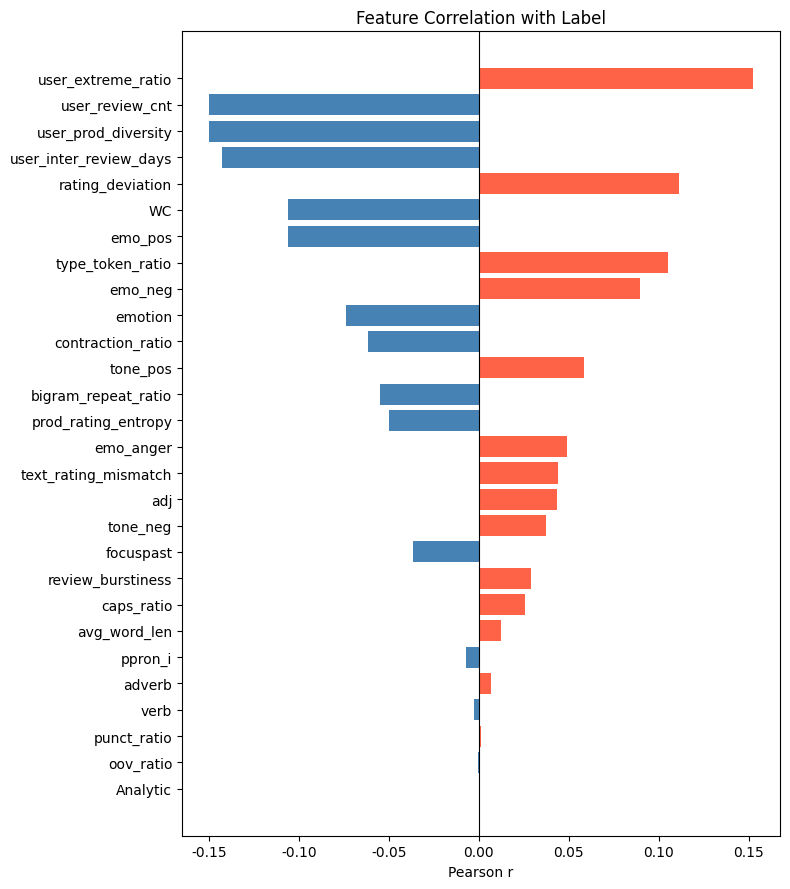

In [15]:
all_feat_cols = sent_cols + auth_cols + template_cols + pos_cols + behav_cols + network_cols
print(f"Total features: {len(all_feat_cols)}")
print(f"  Sentiment {len(sent_cols)} | Text Authenticity {len(auth_cols)} | Template {len(template_cols)} | POS&Pronoun {len(pos_cols)} | Behavioral {len(behav_cols)} | Network {len(network_cols)}")

corr = df_sub[all_feat_cols + ["label"]].corr()["label"].drop("label").sort_values(key=abs, ascending=False)
print("\nCorrelation with label (sorted by |r|):")
print(corr.round(4))

fig, ax = plt.subplots(figsize=(8, 9))
colors = ["tomato" if v > 0 else "steelblue" for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with Label")
ax.set_xlabel("Pearson r")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/feature_corr.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 5-7. 피처 중요도 분석 — Pearson 상관계수

#### 변별력 높은 변수 (|r| > 0.10)

| 변수 | r | 해석 |
|:---|:---:|:---|
| user_extreme_ratio | +0.152 | 극단 별점 비율 높을수록 사기 → 팀 가설 1 검증 ✓ |
| user_review_cnt | -0.150 | 리뷰 수 많을수록 정상 (소수 리뷰어가 사기 경향) |
| user_prod_diversity | -0.150 | 다양한 상품 리뷰할수록 정상 → Zhang et al. Neighbor Diversity 검증 ✓ |
| user_inter_review_days | -0.143 | 리뷰 간격 짧을수록 사기 → 팀 가설 5 검증 ✓ |
| rating_deviation | +0.111 | 상품 평균에서 벗어난 별점일수록 사기 |
| WC | -0.106 | 리뷰가 짧을수록 사기 경향 |
| emo_pos | -0.106 | 강한 긍정 감성일수록 정상 |
| type_token_ratio | +0.105 | 어휘 다양성 높을수록 사기 (역설적; 템플릿 리뷰도 단어는 다양할 수 있음) |

#### 선형 상관이 낮은 변수 (|r| < 0.01)

`ppron_i`, `adverb`, `verb`, `punct_ratio`, `oov_ratio`, `Analytic`

> **참고**: Pearson 상관계수가 낮다고 해서 GNN에서 무의미한 변수가 아니다.  
> GNN은 그래프 구조를 통한 메시지 패싱으로 **비선형 관계**를 학습하며,  
> 단독으로는 약한 피처도 이웃 노드 정보와 결합하면 충분히 변별력을 가질 수 있다.

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.


               feature          category         r
    user_extreme_ratio     Network Proxy  0.152326
       user_review_cnt        Behavioral -0.149814
   user_prod_diversity     Network Proxy -0.149814
user_inter_review_days        Behavioral -0.142722
      rating_deviation     Network Proxy  0.111245
                    WC Text Authenticity -0.106098
               emo_pos         Sentiment -0.106006
      type_token_ratio    Template Proxy  0.105248
               emo_neg         Sentiment  0.089367
               emotion         Sentiment -0.074055
     contraction_ratio Text Authenticity -0.061592
              tone_pos         Sentiment  0.058732
   bigram_repeat_ratio    Template Proxy -0.054850
   prod_rating_entropy     Network Proxy -0.050037
             emo_anger         Sentiment  0.048975
  text_rating_mismatch        Behavioral  0.043883
                   adj     POS & Pronoun  0.043471
              tone_neg         Sentiment  0.037390
             focuspast     POS 

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

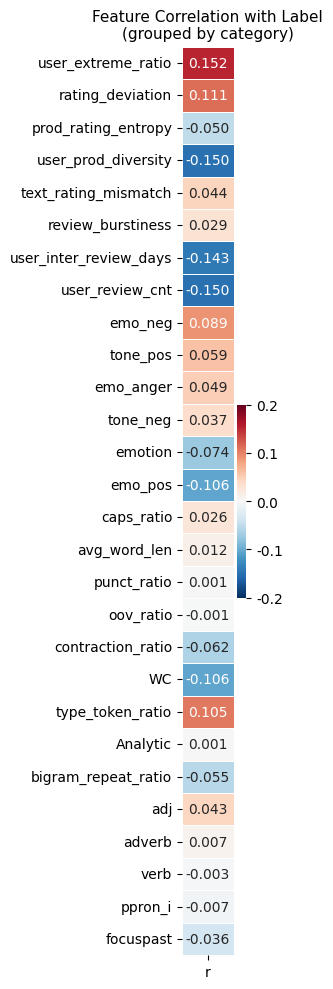

In [16]:
import seaborn as sns

# 상관계수 DataFrame
corr_df = corr.reset_index()
corr_df.columns = ["feature", "r"]
corr_df["abs_r"] = corr_df["r"].abs()
corr_df["category"] = corr_df["feature"].map({
    **{c: "Sentiment"         for c in sent_cols},
    **{c: "Text Authenticity" for c in auth_cols},
    **{c: "Template Proxy"    for c in template_cols},
    **{c: "POS & Pronoun"     for c in pos_cols},
    **{c: "Behavioral"        for c in behav_cols},
    **{c: "Network Proxy"     for c in network_cols},
})

print(corr_df[["feature", "category", "r"]].to_string(index=False))

# 히트맵 (카테고리별 그룹)
cat_order = ["Network Proxy", "Behavioral", "Sentiment", "Text Authenticity", "Template Proxy", "POS & Pronoun"]
corr_ordered = pd.concat([
    corr_df[corr_df["category"] == cat].sort_values("r", ascending=False)
    for cat in cat_order
])

fig, ax = plt.subplots(figsize=(3, 10))
heatmap_data = corr_ordered.set_index("feature")[["r"]]
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".3f", cmap="RdBu_r", center=0,
    vmin=-0.2, vmax=0.2,
    linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.6}
)
ax.set_title("Feature Correlation with Label\n(grouped by category)", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/feature_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.


               feature          category         r
    user_extreme_ratio     Network Proxy  0.152326
       user_review_cnt        Behavioral -0.149814
   user_prod_diversity     Network Proxy -0.149814
user_inter_review_days        Behavioral -0.142722
      rating_deviation     Network Proxy  0.111245
                    WC Text Authenticity -0.106098
               emo_pos         Sentiment -0.106006
      type_token_ratio    Template Proxy  0.105248
               emo_neg         Sentiment  0.089367
               emotion         Sentiment -0.074055
     contraction_ratio Text Authenticity -0.061592
              tone_pos         Sentiment  0.058732
   bigram_repeat_ratio    Template Proxy -0.054850
   prod_rating_entropy     Network Proxy -0.050037
             emo_anger         Sentiment  0.048975
  text_rating_mismatch        Behavioral  0.043883
                   adj     POS & Pronoun  0.043471
              tone_neg         Sentiment  0.037390
             focuspast     POS 

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

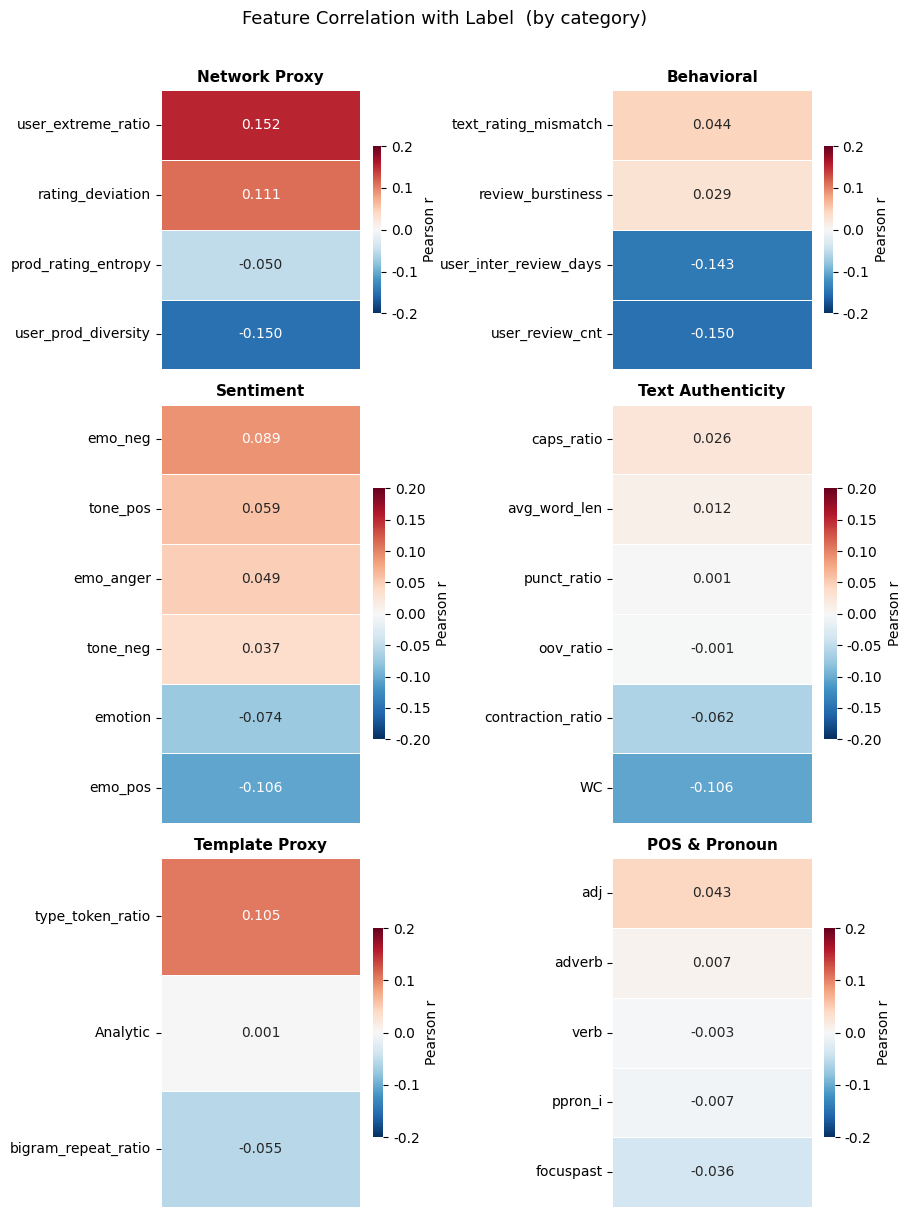

In [17]:
import seaborn as sns

# 상관계수 DataFrame
corr_df = corr.reset_index()
corr_df.columns = ["feature", "r"]
corr_df["abs_r"] = corr_df["r"].abs()
corr_df["category"] = corr_df["feature"].map({
    **{c: "Sentiment"         for c in sent_cols},
    **{c: "Text Authenticity" for c in auth_cols},
    **{c: "Template Proxy"    for c in template_cols},
    **{c: "POS & Pronoun"     for c in pos_cols},
    **{c: "Behavioral"        for c in behav_cols},
    **{c: "Network Proxy"     for c in network_cols},
})

print(corr_df[["feature", "category", "r"]].to_string(index=False))

def n_feat(cat):
    return len(corr_df[corr_df["category"] == cat])

# 3행 × 2열 그리드: 피처 수가 비슷한 카테고리끼리 같은 행에 배치
cat_grid = [
    ["Network Proxy",  "Behavioral"],        # 4, 4
    ["Sentiment",      "Text Authenticity"], # 6, 6
    ["Template Proxy", "POS & Pronoun"],     # 3, 5
]
row_heights = [max(n_feat(cat) for cat in row) for row in cat_grid]

fig, axes = plt.subplots(
    3, 2, figsize=(9, 12),
    gridspec_kw={"height_ratios": row_heights}
)

for r_i, row_cats in enumerate(cat_grid):
    for c_i, cat in enumerate(row_cats):
        ax = axes[r_i][c_i]
        sub = corr_df[corr_df["category"] == cat].sort_values("r", ascending=False)
        hm_data = sub.set_index("feature")[["r"]]

        sns.heatmap(
            hm_data,
            annot=True, fmt=".3f",
            cmap="RdBu_r", center=0, vmin=-0.2, vmax=0.2,
            linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.6, "label": "Pearson r"},
        )
        ax.set_title(cat, fontsize=11, fontweight="bold", pad=6)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", bottom=False, labelbottom=False)

plt.suptitle("Feature Correlation with Label  (by category)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/feature_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
save_cols = (
    ["node_id", "user_id", "prod_id", "user_int", "prod_int", "rating", "label", "date", "year_month"]
    + sent_cols + auth_cols + template_cols + pos_cols + behav_cols + network_cols
)

df_nodes = df_sub[save_cols].copy()
out_path = f"{OUT_DIR}/Preprocessing_0512.csv"
df_nodes.to_csv(out_path, index=False)

print(f"저장 완료: {out_path}")
print(f"shape: {df_nodes.shape}  ({len(all_feat_cols)}개 피처)")
print(df_nodes.head(3))

저장 완료: c:\Users\user\Desktop\project_DScover_연합학술제_GNN\pipeline_이유준/Preprocessing_0512.csv
shape: (44776, 36)  (28개 피처)
   node_id  user_id  prod_id  user_int  prod_int  rating  label year_month  \
0        0     5049        0         0         0       5      1    2013-07   
1        1     5050        0         1         0       5      1    2013-03   
2        2     5104        0         2         0       3      0    2013-07   

   tone_pos  tone_neg  ...  ppron_i  focuspast  user_review_cnt  \
0     0.245     0.000  ...      0.0   0.045977                1   
1     0.543     0.000  ...      0.0   0.000000                1   
2     0.217     0.083  ...      0.0   0.080000                5   

   user_inter_review_days  text_rating_mismatch  review_burstiness  \
0                   -1.00                     0           0.000000   
1                   -1.00                     0           0.000000   
2                   35.75                     0           0.263606   

   user_prod_dive